# Lab 01 - Classifying Spam Emails

Notebook này đi theo flow phân tích rõ ràng từ data đến model qua các bước tối ưu sau:

| Bước | Tên Bước | Nội dung | Thư mục/Mã nguồn liên quan |
| --- | --- | --- | --- |
| **Step 0** | Setup & Imports | Thiết lập đường dẫn thư mục dự án và nạp các thư viện, module bổ trợ. | `notebooks/utils.py`, `notebooks/model_from_scratch.py` |
| **STEP 1** | Read Data | Đọc tập dữ liệu Raw và tập dữ liệu nhẹ đã qua xử lý sơ bộ. Kiểm tra thông tin & thống kê mô tả. | `crawl.load_datasets` |
| **STEP 2** | Raw Data EDA | Phân tích và trực quan hóa phân phối nhãn (label) và nguồn dữ liệu (sources) trên tập Raw. | `eda.plot_label_distribution` |
| **STEP 3** | Check Quality (Raw) | Kiểm tra tỷ lệ khuyết thiếu (missing data) và số dòng trùng lặp (duplicates) trong tập Raw. | `preprocess.missing_data_summary` |
| **STEP 4** | Clean & Preprocess | Tiến hành làm sạch văn bản email, lọc dữ liệu huấn luyện, kiểm tra chất lượng sau tiền xử lý. | `preprocess.clean_email_text` |
| **STEP 5** | Processed Data EDA | Trực quan hóa và phân tích phân phối dữ liệu đã làm sạch nhưng chưa cân bằng (Unbalanced). | `eda.plot_eda_overview` |
| **STEP 6** | Balance & Unbalance EDA | Cân bằng dữ liệu (downsampling) để ham/spam tỷ lệ 1:1, phân tích sự thay đổi phân phối. | `preprocess.balance_dataset` |
| **STEP 7** | Feature Engineering | Trích xuất và xem trước đặc trưng TF-IDF được sinh ra từ tập văn bản email. | `model_checker.tfidf_feature_preview` |
| **STEP 8** | Split Data | Tải thêm dữ liệu ham mới (V2) và chia tập dữ liệu huấn luyện/kiểm thử (Train/Test Split). | `utils.prepare_fixed_split` |
| **STEP 9** | Train & Double Check | Huấn luyện 3 mô hình trên 3 tập dữ liệu khác nhau, kiểm tra logic các mô hình tự viết (from scratch) vs. sklearn. | `utils.run_three_data_model_comparison` |
| **STEP 10** | Threshold Tuning | Dò tìm ngưỡng tối ưu trên tập Validation phục vụ mục tiêu TPR ~99% và FPR ~1%, thực hiện phân tích lỗi. | `utils.run_threshold_tuning` |
| **STEP 11** | Save Model | Lưu trữ mô hình tối ưu, thử nghiệm nhận diện email mới và kiểm tra báo cáo dự án. | `model_checker.save_model` |


## Step 0 — Import Libraries And Setup


In [2]:
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

for module_path in [NOTEBOOKS_DIR, PROJECT_ROOT]:
    module_path = str(module_path)
    if module_path in sys.path:
        sys.path.remove(module_path)
    sys.path.insert(0, module_path)

import crawl
import preprocess
import model_from_scratch
import eda
import utils

crawl = importlib.reload(crawl)
preprocess = importlib.reload(preprocess)
model_from_scratch = importlib.reload(model_from_scratch)
eda = importlib.reload(eda)
utils = importlib.reload(utils)
model_checker = model_from_scratch.SklearnModelChecker()

paths = crawl.project_paths(PROJECT_ROOT)
print(f"crawl module: {crawl.__file__}")
print(f"preprocess module: {preprocess.__file__}")
print(f"model module: {model_from_scratch.__file__}")
print(f"eda module: {eda.__file__}")
print(f"utils module: {utils.__file__}")
PROJECT_ROOT

crawl module: /Users/quangmanh/Project/lab01/notebooks/crawl.py
preprocess module: /Users/quangmanh/Project/lab01/notebooks/preprocess.py
model module: /Users/quangmanh/Project/lab01/notebooks/model_from_scratch.py
eda module: /Users/quangmanh/Project/lab01/notebooks/eda.py
utils module: /Users/quangmanh/Project/lab01/notebooks/utils.py


PosixPath('/Users/quangmanh/Project/lab01')

## STEP 1 — Read Data: Raw + Light Processed Data

Load dữ liệu raw và file processed hiện có để đối chiếu. Hiển thị head, info, và describe của tập dữ liệu raw.


In [3]:
data, raw_data, paths = crawl.load_datasets(PROJECT_ROOT)
processed_data = data.copy().reset_index(drop=True)
overview = crawl.dataset_overview(processed_data, raw_data)

print(f"Processed rows: {overview['processed_rows']:,}")
print(f"Raw rows: {overview['raw_rows']:,}" if overview["raw_rows"] else "Raw dataset not found")

print("\n--- Raw data head ---")
display(raw_data.head(3))

print("\n--- Raw data info ---")
raw_data.info()

Processed rows: 9,886
Raw rows: 18,807

--- Raw data head ---


,email_id,source,source_family,source_url,local_path,extracted_from,extracted_path,archive_path,label,sender,recipient,subject,body,text
0,ce51395fd8e8257c13facf3140cfb9496fedc8cada23f1...,spamassassin_20021010_easy_ham,spamassassin,https://spamassassin.apache.org/old/publiccorp...,/Users/quangmanh/Project/lab01/data/raw/downlo...,/Users/quangmanh/Project/lab01/data/raw/downlo...,easy_ham/1011.82f644586fced13704dd79e22c3d8fb9,easy_ham/1011.82f644586fced13704dd79e22c3d8fb9,ham,John Hall <johnhall@evergo.net>,fork@example.com,RE: The Curse of India's Socialism,> From: fork-admin@xent.com [mailto:fork-admin...,RE: The Curse of India's Socialism > From: for...
1,fb481d334002f416cff290374cff170831ea647f93dc8a...,spamassassin_20021010_easy_ham,spamassassin,https://spamassassin.apache.org/old/publiccorp...,/Users/quangmanh/Project/lab01/data/raw/downlo...,/Users/quangmanh/Project/lab01/data/raw/downlo...,easy_ham/1051.cf81a19208b703f18497a0d6fedb1f13,easy_ham/1051.cf81a19208b703f18497a0d6fedb1f13,ham,Ingo Frommholz <ingo@frommholz.org>,exmh-users@example.com,"Re: ARRRGHHH Had GPG working, now it doesnt.","Hi,\n\nOn Sun, 01 Sep 2002 00:05:03 MDT Reg Cl...","Re: ARRRGHHH Had GPG working, now it doesnt. H..."
2,95d692d420799d95e442a19b697ad72ad3d8716aeac3d9...,spamassassin_20021010_easy_ham,spamassassin,https://spamassassin.apache.org/old/publiccorp...,/Users/quangmanh/Project/lab01/data/raw/downlo...,/Users/quangmanh/Project/lab01/data/raw/downlo...,easy_ham/1091.0bade8676340d304cae87dad02efa8ce,easy_ham/1091.0bade8676340d304cae87dad02efa8ce,ham,Tony Nugent <tony@linuxworks.com.au>,exmh-users@example.com,Re: bad focus/click behaviours,"On Fri Sep 13 2002 at 02:03, Robert Elz wrote:...",Re: bad focus/click behaviours On Fri Sep 13 2...



--- Raw data info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18807 entries, 0 to 18806
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   email_id        18807 non-null  object
 1   source          18807 non-null  object
 2   source_family   18807 non-null  object
 3   source_url      18807 non-null  object
 4   local_path      18807 non-null  object
 5   extracted_from  18807 non-null  object
 6   extracted_path  18807 non-null  object
 7   archive_path    18807 non-null  object
 8   label           18807 non-null  object
 9   sender          18807 non-null  object
 10  recipient       18807 non-null  object
 11  subject         18807 non-null  object
 12  body            18807 non-null  object
 13  text            18807 non-null  object
dtypes: object(14)
memory usage: 2.0+ MB


## STEP 2 — EDA with raw

Phân tích phân phối nhãn và nguồn dữ liệu của tập dữ liệu raw.


In [4]:
raw_eda_frame = raw_data if not raw_data.empty else data
display(crawl.label_counts(raw_eda_frame))
display(crawl.source_counts(raw_eda_frame, top_n=15))

,label,rows
0,ham,13616
1,spam,5191


,source_family,rows
0,spamassassin,5187
1,kaggle_enron_email_dataset,5000
2,kaggle_email_spam_classification,1000
3,aueb_enron3_spam_ham,999
4,huggingface_enron_spam,996
5,aueb_enron2_spam_ham,995
6,aueb_enron1_spam_ham,992
7,huggingface_kimdongh_spam_dataset,981
8,aueb_enron4_spam_ham,963
9,aueb_enron6_spam_ham,925


## STEP 3 — Check Missing and Duplicates in Raw Data

Kiểm tra chất lượng dữ liệu: tìm giá trị thiếu (missing value) và các dòng bị trùng lặp (duplicates) trong raw dataset.


,column,missing_count,missing_percent,dtype
0,archive_path,0,0.0,object
1,body,0,0.0,object
2,email_id,0,0.0,object
3,extracted_from,0,0.0,object
4,extracted_path,0,0.0,object
5,label,0,0.0,object
6,local_path,0,0.0,object
7,recipient,0,0.0,object
8,sender,0,0.0,object
9,source,0,0.0,object


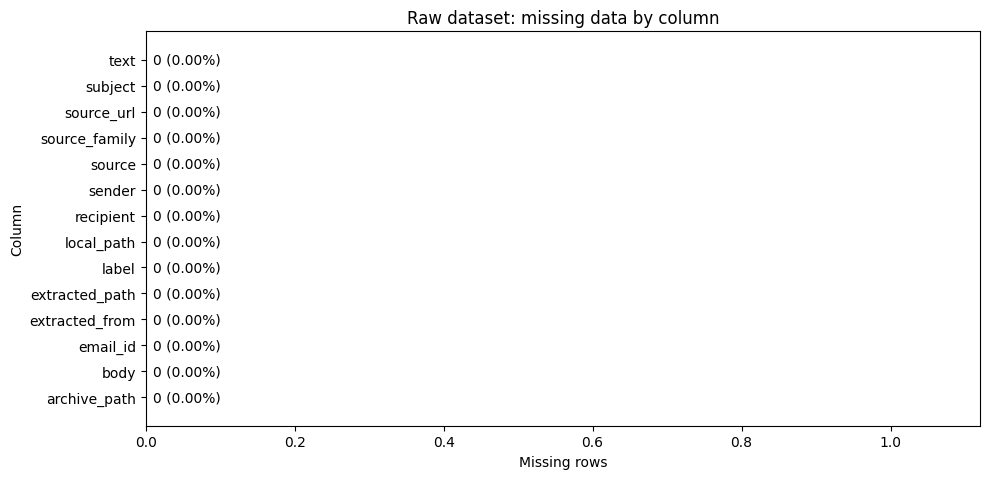

,subset,total_rows,unique_rows,duplicate_rows,duplicate_percent
0,all columns,18807,18807,0,0.0


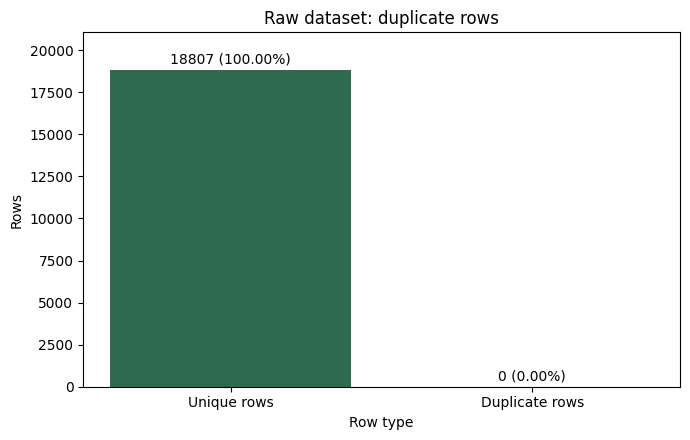

In [5]:
missing_summary = preprocess.missing_data_summary(raw_data)
display(missing_summary)
preprocess.plot_missing_data(raw_data, title="Raw dataset: missing data by column")

duplicate_summary = preprocess.duplicate_data_summary(raw_data)
display(duplicate_summary)
preprocess.plot_duplicate_data(raw_data, title="Raw dataset: duplicate rows")


## STEP 4 — Process raw. Clean and preprocess email text.

Sử dụng code trong `notebooks/preprocess.py` để làm sạch dữ liệu.


In [6]:
display(preprocess.processed_sample(data, rows=3, random_state=42))

raw_example, clean_example = preprocess.example_cleaning()
print("Raw example:")
print(raw_example)
print("\nCleaned example using notebooks/preprocess.py:")
print(clean_example)


,label,source_family,subject,body,clean_text
4170,spam,aueb_enron2_spam_ham,undeliverable : home based business for grownups,your message\r\nsubject : home based business ...,undeliverable home based business grownups mes...
5809,ham,spamassassin,Re: [ILUG] SUSE 8 disks? (thread changed sligh...,wintermute <cout@eircom.net> a écrit:\n\n\n> >...,ilug suse disks thread changed slightly winter...
3023,ham,kaggle_enron_email_dataset,,Message-ID: <15581064.1075855710484.JavaMail.e...,message-id javamail evans thyme tue mar pst mi...


Raw example:
<html><body><h1>WIN MONEY NOW!!!</h1>
Click https://example.com/prize and email winner@example.com to claim $5,000 today.
</body></html>

Cleaned example using notebooks/preprocess.py:
win money claim today


### STEP 4.1 — Raw-To-Clean Check On Real Rows

Cell này chứng minh preprocessing chạy trên dữ liệu raw thật, không chỉ trên ví dụ tự tạo.


In [7]:
raw_to_clean = preprocess.raw_to_clean_sample(raw_data, rows=5)
if raw_to_clean.empty:
    print("Raw dataset is not available, so this check is skipped.")
else:
    display(raw_to_clean)

,label,source_family,text,clean_text,raw_char_count,clean_char_count,clean_word_count
0,ham,spamassassin,RE: The Curse of India's Socialism > From: for...,curse india's socialism behalf james rogers cu...,1601,846,114
1,ham,spamassassin,"Re: ARRRGHHH Had GPG working, now it doesnt. H...",arrrghhh gpg working doesnt hi sun sep mdt reg...,987,460,69
2,ham,spamassassin,Re: bad focus/click behaviours On Fri Sep 13 2...,bad focus behaviours fri sep robert elz wrote ...,1527,674,102
3,ham,spamassassin,"Re: ALSA (almost) made easy On Thu, 2002-08-29...",alsa easy thu matthias saou wrote thanks lot r...,1442,699,108
4,ham,spamassassin,creating rpms with subdirs (install command) H...,creating rpms subdirs install command hi i'm b...,803,365,53


### STEP 4.2 — Quality check on data after preprocess

Kiểm tra lại missing và duplicate sau khi tiền xử lý dữ liệu.


In [8]:
full_clean_data, before_balance_data, unbalanced_processed_data = utils.run_preprocess_step(raw_data)

Full cleaned rows: 18,323
Trainable rows after preprocess, before balance: 12,960
Unbalanced label counts


,label,rows
0,ham,8291
1,spam,4669


After preprocess, before balance: missing data in model/features columns


,column,missing_count,missing_percent,dtype
0,clean_char_count,0,0.0,int64
1,clean_text,0,0.0,object
2,clean_word_count,0,0.0,int64
3,label,0,0.0,object
4,raw_char_count,0,0.0,int64
5,source_family,0,0.0,object
6,subject,0,0.0,object
7,text,0,0.0,object


After preprocess, before balance: duplicate clean_text + label


,subset,total_rows,unique_rows,duplicate_rows,duplicate_percent
0,"clean_text, label",12960,12960,0,0.0


label,source_family,ham,spam,total,spam_rate
9,spamassassin,4091,668,4759,0.1404
2,aueb_enron3_spam_ham,493,494,987,0.5005
8,kaggle_email_spam_classification,437,547,984,0.5559
1,aueb_enron2_spam_ham,490,488,978,0.4990
0,aueb_enron1_spam_ham,491,456,947,0.4815
3,aueb_enron4_spam_ham,492,444,936,0.4744
7,huggingface_kimdongh_spam_dataset,471,446,917,0.4864
5,aueb_enron6_spam_ham,480,423,903,0.4684
6,huggingface_enron_spam,384,404,788,0.5127
4,aueb_enron5_spam_ham,462,299,761,0.3929


,analysis_char_count,analysis_word_count,subject_chars
count,12960.000000,12960.000000,12960.000000
mean,924.435802,124.972685,28.440895
std,2435.276217,286.998275,24.190895
min,25.000000,5.000000,0.000000
25%,239.750000,34.000000,10.000000
50%,474.500000,68.000000,27.000000
75%,942.000000,132.000000,42.000000
95%,2824.100000,379.050000,68.000000
max,120772.000000,15414.000000,452.000000


## STEP 5 — EDA with data after process

Đây là data đã clean và lọc trainable nhưng chưa cân bằng (unbalanced).


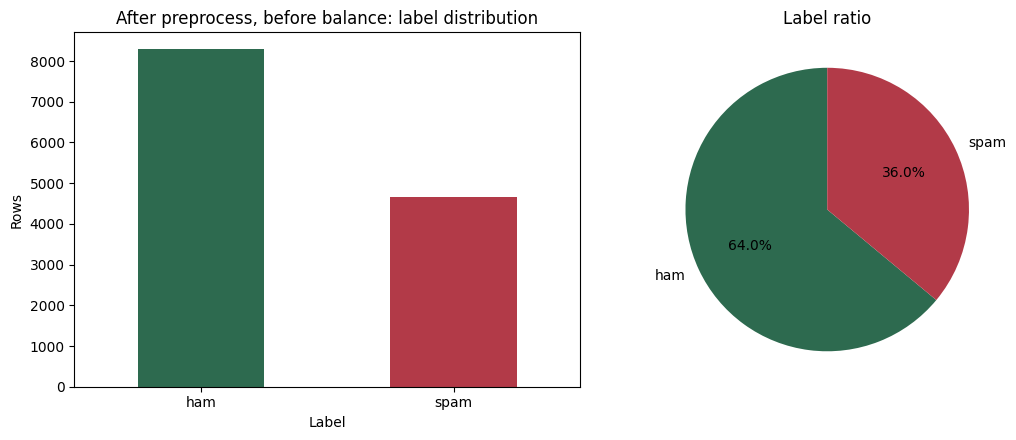

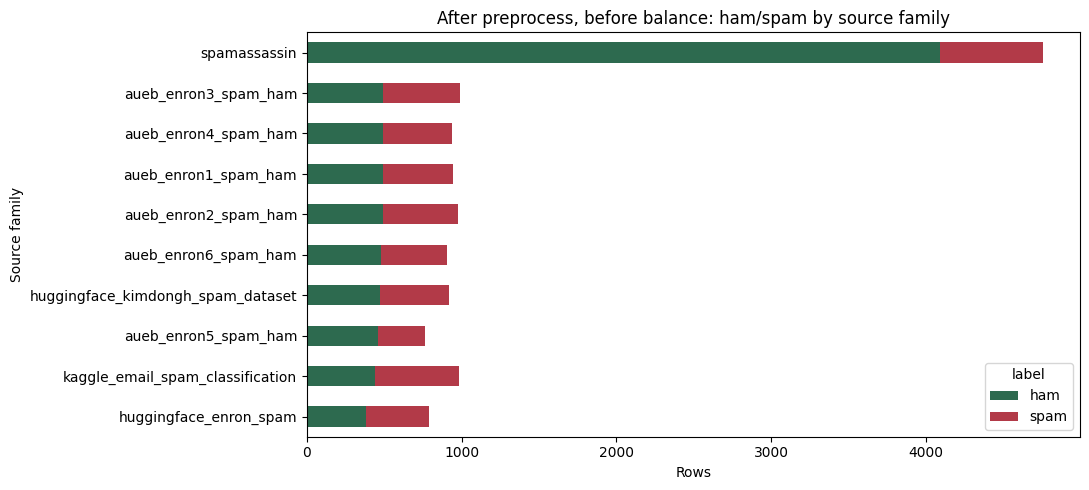

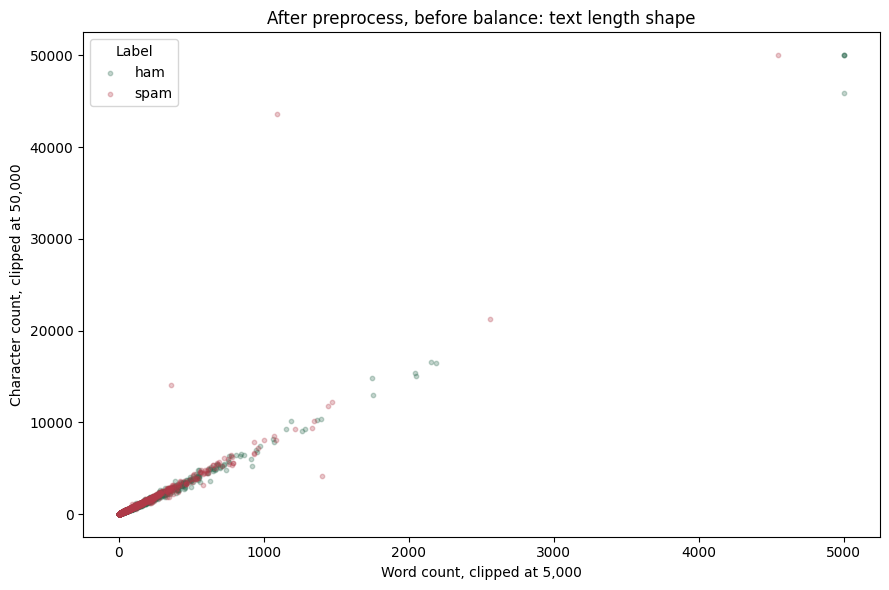

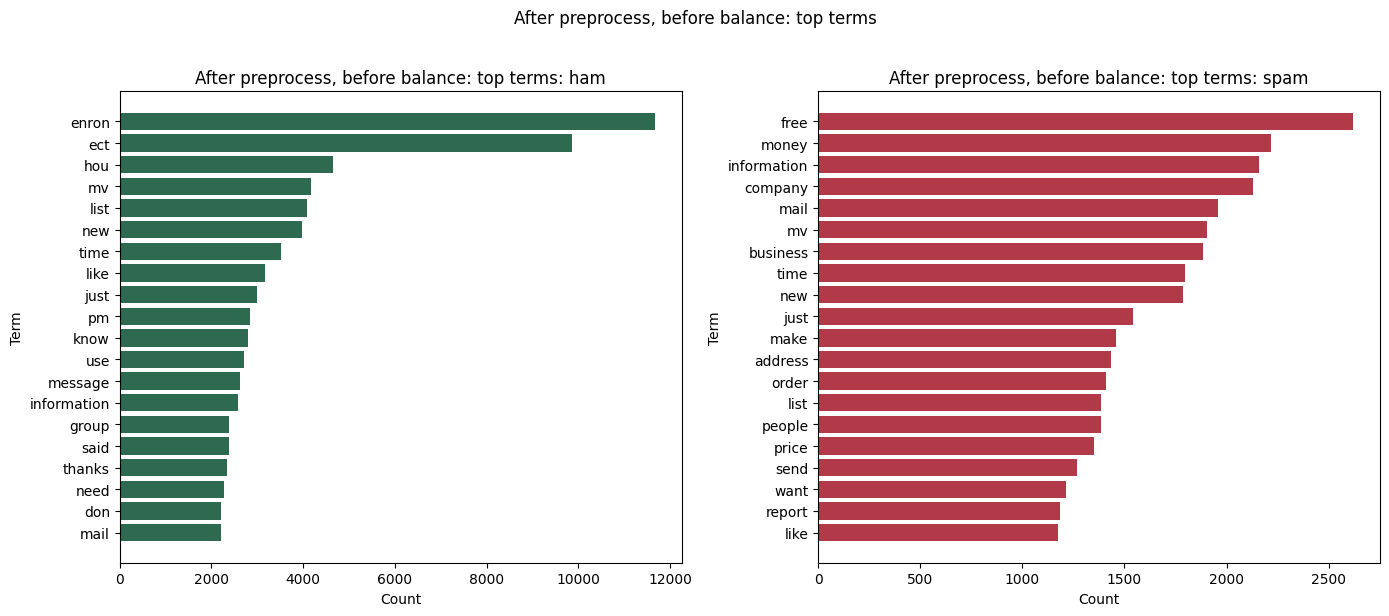

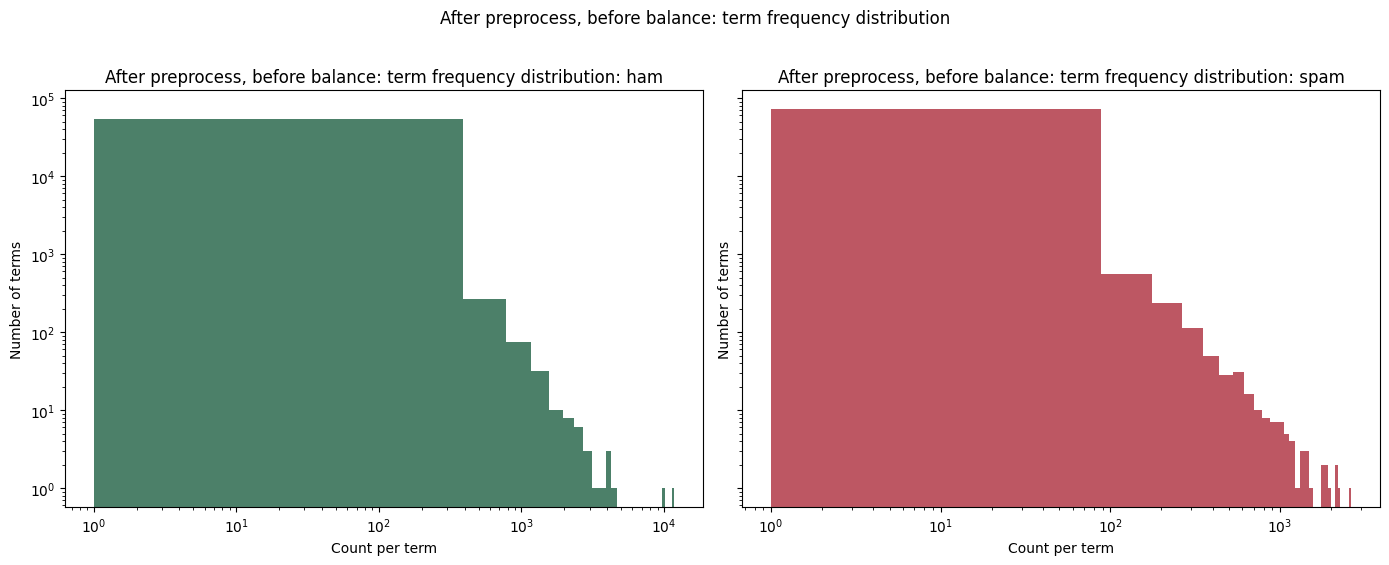

In [9]:
eda = importlib.reload(eda)
eda.plot_eda_overview(before_balance_data, title_prefix="After preprocess, before balance")

## STEP 6 — Balance and Unbalance data (with EDA)

Cân bằng tập dữ liệu và so sánh phân phối trước/sau khi cân bằng.


In [10]:
balanced_data = preprocess.balance_dataset(before_balance_data, random_seed=42)

print(f"Before balance rows: {len(before_balance_data):,}")
print(f"Balanced rows: {len(balanced_data):,}")
print("Before balance label counts")
display(crawl.label_counts(before_balance_data))
print("After balance label counts")
display(crawl.label_counts(balanced_data))
display(eda.source_label_table(balanced_data).head(20))
display(eda.length_summary(balanced_data))

Before balance rows: 12,960
Balanced rows: 9,002
Before balance label counts


,label,rows
0,ham,8291
1,spam,4669


After balance label counts


,label,rows
0,ham,4501
1,spam,4501


label,source_family,ham,spam,total,spam_rate
8,kaggle_email_spam_classification,437,547,984,0.5559
9,spamassassin,460,500,960,0.5208
2,aueb_enron3_spam_ham,460,494,954,0.5178
1,aueb_enron2_spam_ham,460,488,948,0.5148
0,aueb_enron1_spam_ham,460,456,916,0.4978
7,huggingface_kimdongh_spam_dataset,460,446,906,0.4923
3,aueb_enron4_spam_ham,460,444,904,0.4912
5,aueb_enron6_spam_ham,460,423,883,0.4790
6,huggingface_enron_spam,384,404,788,0.5127
4,aueb_enron5_spam_ham,460,299,759,0.3939


,analysis_char_count,analysis_word_count,subject_chars
count,9002.000000,9002.000000,9002.000000
mean,930.903244,125.043657,24.585425
std,2457.019088,281.331753,25.115546
min,25.000000,5.000000,0.000000
25%,230.000000,33.000000,0.000000
50%,472.000000,67.000000,22.000000
75%,1009.000000,139.000000,38.000000
95%,2859.900000,382.950000,67.000000
max,120772.000000,15414.000000,452.000000


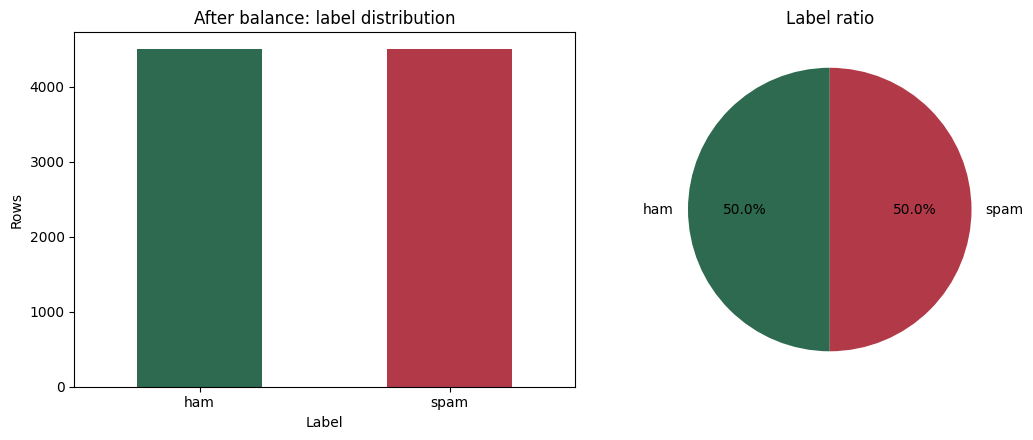

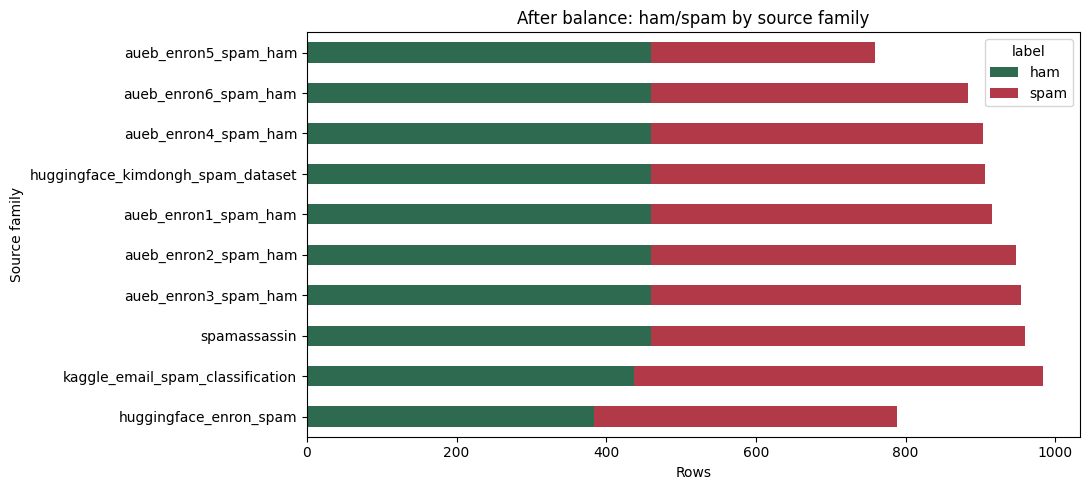

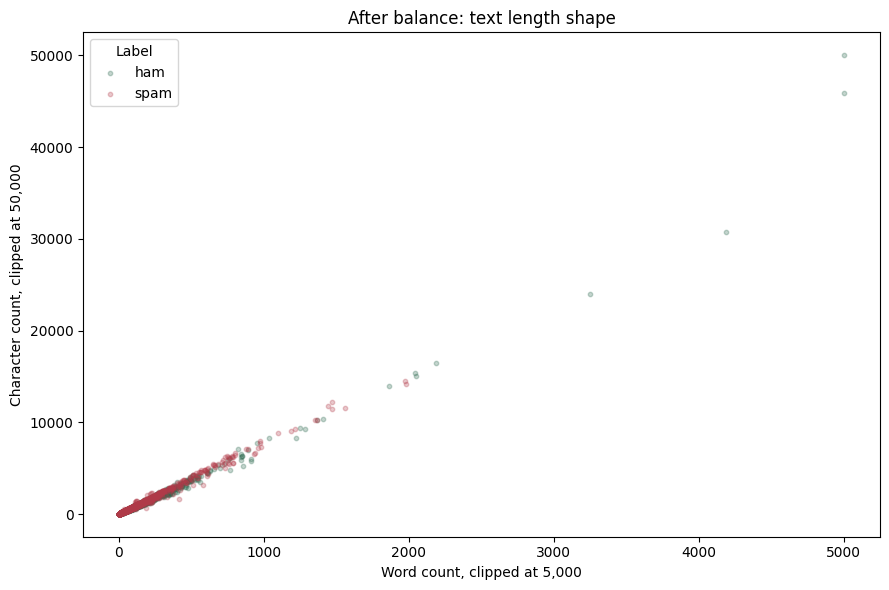

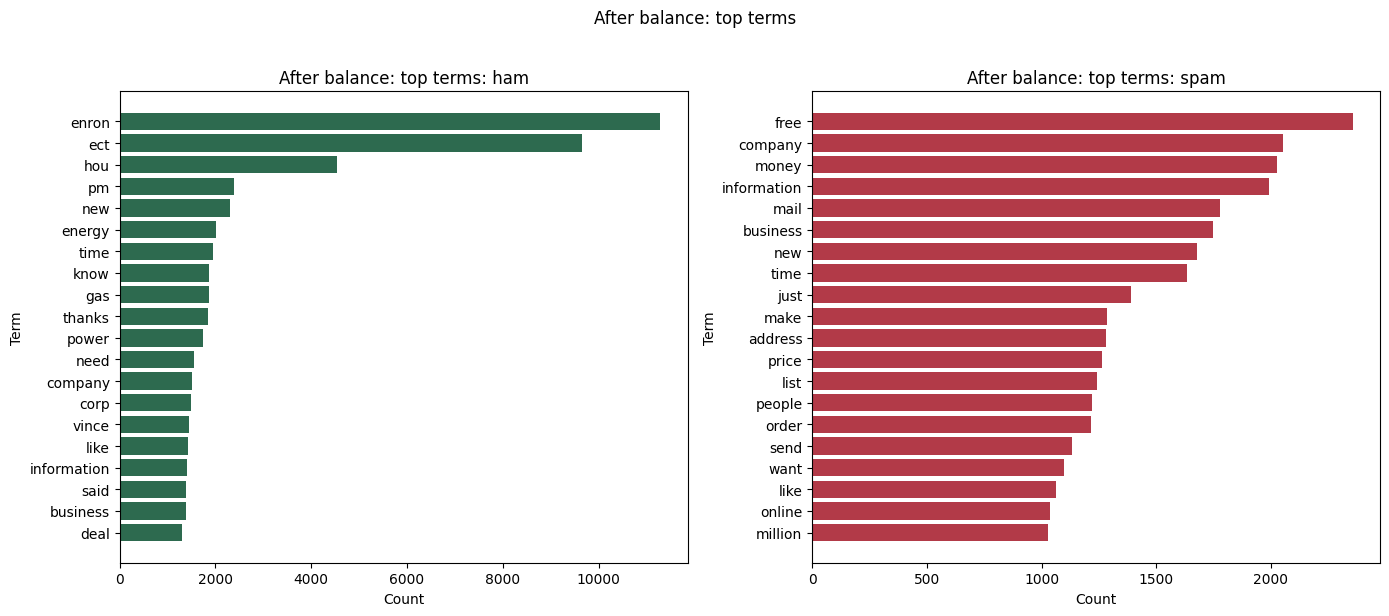

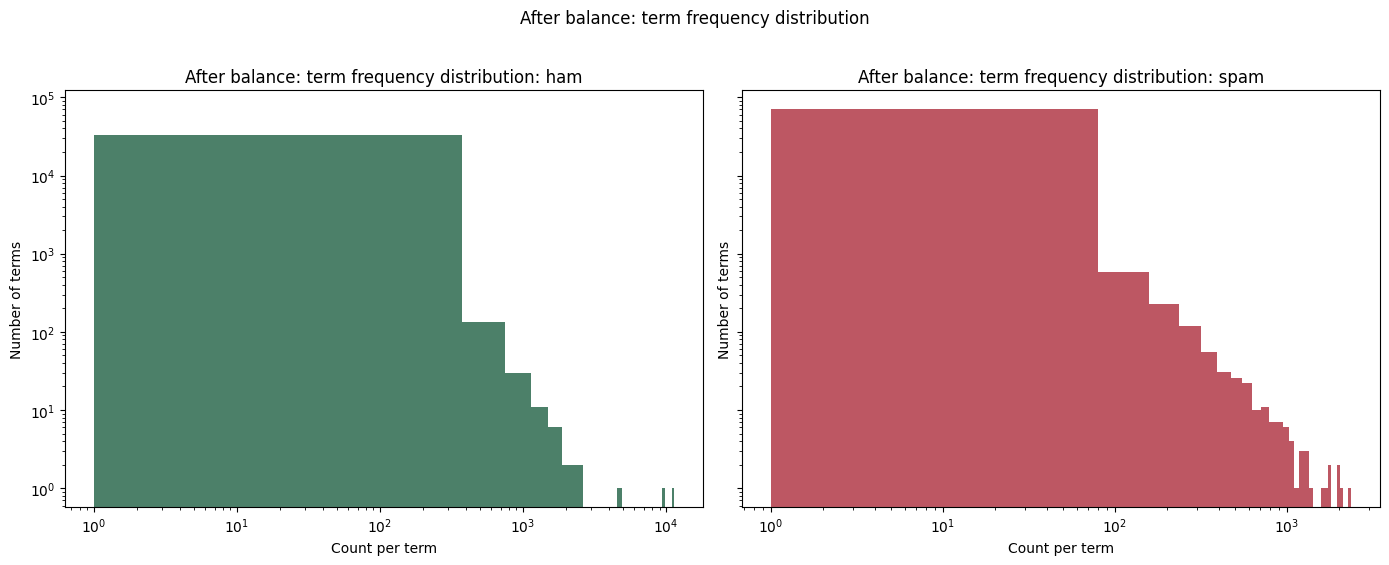

In [11]:
eda = importlib.reload(eda)
eda.plot_eda_overview(balanced_data, title_prefix="After balance")

### STEP 6 Notes — EDA Reading

So sánh Step 5 và Step 6 để thấy trade-off của downsample balance.


## STEP 7 — Feature Engineering: TF-IDF

Trích xuất đặc trưng bằng TF-IDF.


In [12]:
tfidf_shape, tfidf_features = model_checker.tfidf_feature_preview(balanced_data["clean_text"], preview_count=30)

print(f"TF-IDF matrix shape: {tfidf_shape[0]:,} emails x {tfidf_shape[1]:,} features")
print("Example features:")
print(tfidf_features)


TF-IDF matrix shape: 9,002 emails x 174,970 features
Example features:
['000' '000e' '000e mails' '01pm' '01t04' '03t14' '04pm' '04pm dermot'
 '06t18' '06t18 game' '07t03' '0e' '0e irq' '0ne' '0ne million' '0x220'
 '0x220 10baset' '0x300' '0x300 10baset' '100k' '100k cash' '105th'
 '105th congress' '10baset' '10baset port' '10th' '11b' '11th' '128mb'
 '128mb ram']


## STEP 8 — Split data in Balance and Unbalance & Load Ham Data V2

Tải tập dữ liệu ham mở rộng (V2) và chia tập dữ liệu fixed train/test split.


Data v2 rows after preprocess filter: 5,934


,label,rows
0,ham,5934


,source_family,rows
0,v2_kaggle_enron_email_dataset,4943
1,v2_spamassassin_20030228_easy_ham_2,991


label,source_family,ham,spam,total,spam_rate
0,v2_kaggle_enron_email_dataset,4943,0,4943,0.0
1,v2_spamassassin_20030228_easy_ham_2,991,0,991,0.0


,analysis_char_count,analysis_word_count,subject_chars
count,5934.000000,5934.000000,5934.000000
mean,928.032861,128.931918,6.285137
std,1465.312595,200.766991,15.372577
min,31.000000,7.000000,0.000000
25%,360.000000,49.000000,0.000000
50%,545.000000,76.000000,0.000000
75%,960.000000,135.000000,0.000000
95%,2662.200000,373.000000,47.000000
max,38685.000000,5114.000000,109.000000


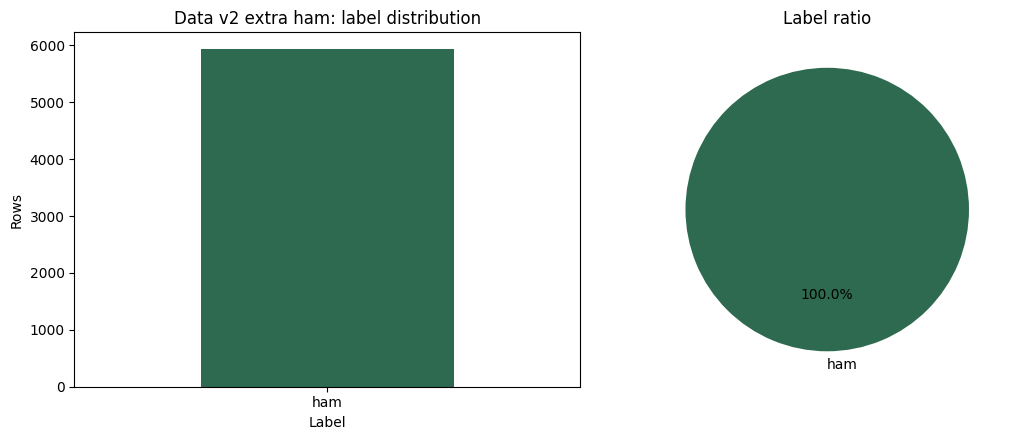

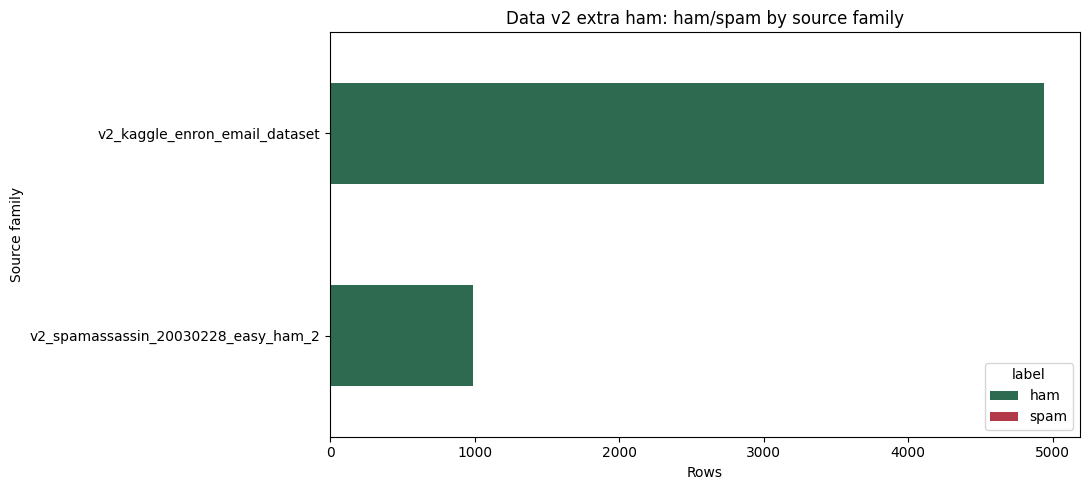

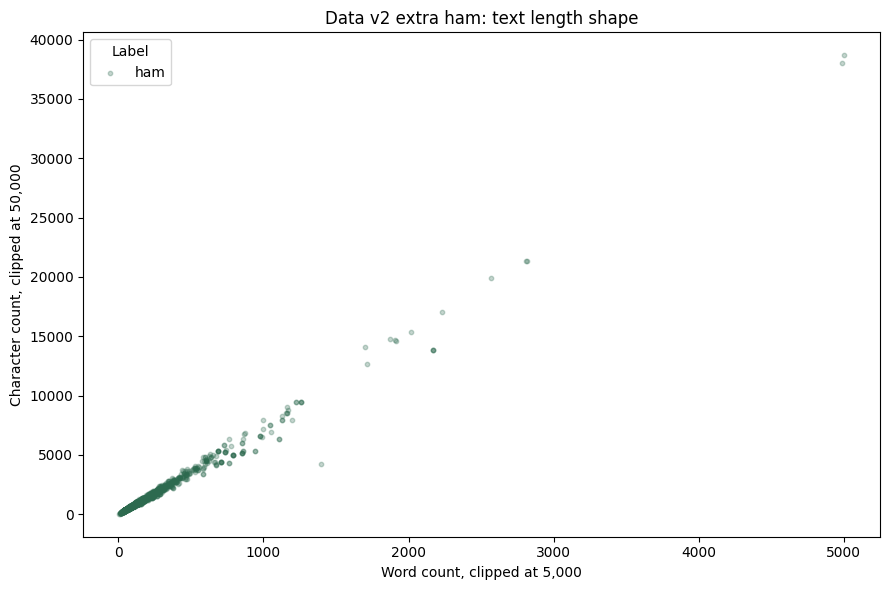

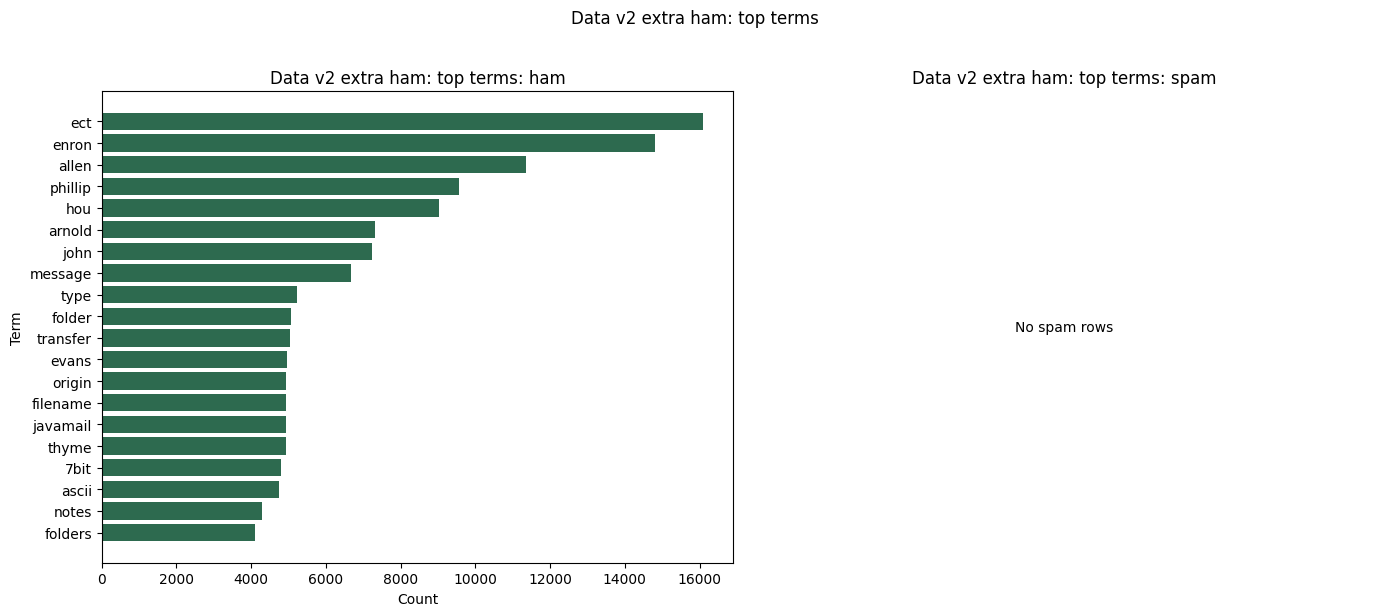

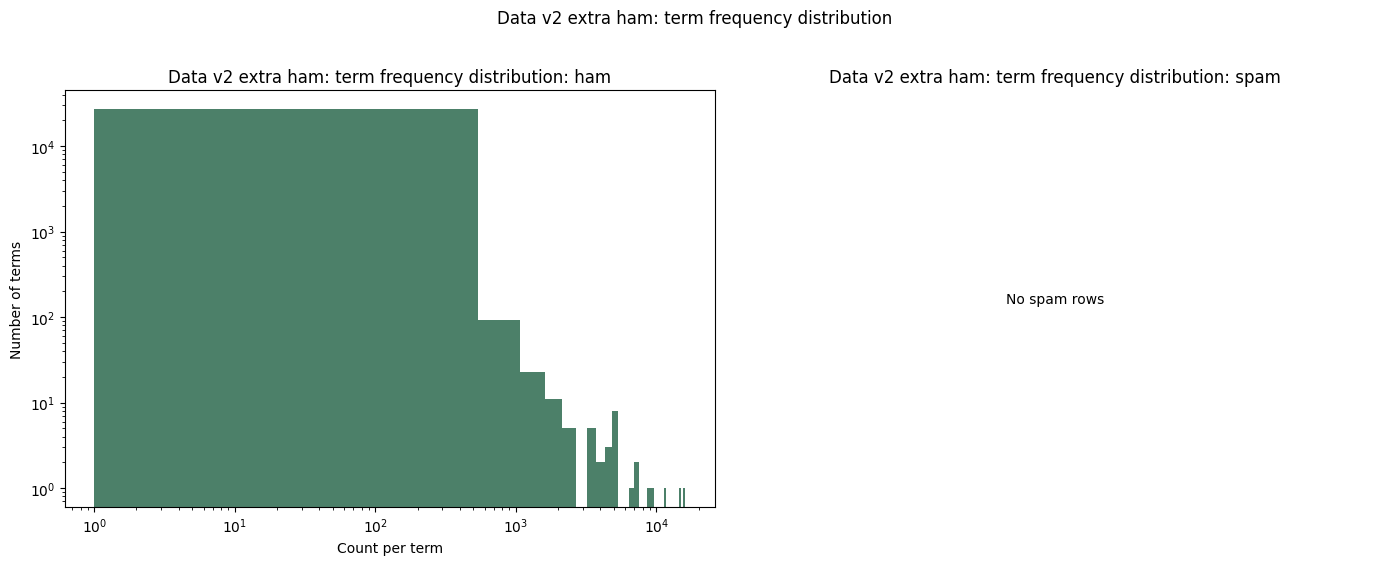

In [13]:
data_v2 = utils.load_and_show_data_v2(PROJECT_ROOT)

In [14]:
split_context = utils.prepare_fixed_split(processed_data)
comparison_base_data = split_context.comparison_base_data
TEXT_COLUMN = split_context.text_column
base_train_data = split_context.base_train_data
base_test_data = split_context.base_test_data
train_data = split_context.train_data
test_data = split_context.test_data
x_train, y_train = split_context.x_train, split_context.y_train
x_test, y_test = split_context.x_test, split_context.y_test

Text column: clean_text


,split,rows,ham,spam
0,processed_base_train,7908,4345,3563
1,balanced_train_for_baseline,7126,3563,3563
2,fixed_processed_test,1978,1088,890


label,ham,spam
source_family,,
aueb_enron1_spam_ham,385,361
aueb_enron2_spam_ham,392,389
aueb_enron3_spam_ham,393,394
aueb_enron4_spam_ham,390,354
aueb_enron5_spam_ham,370,239
aueb_enron6_spam_ham,380,337
huggingface_enron_spam,304,321
huggingface_kimdongh_spam_dataset,374,356
kaggle_email_spam_classification,346,417


## STEP 9 — Train with 3 model (from scratch vs sklearn)

Huấn luyện 3 thuật toán tự code (from scratch) so sánh đối chiếu với thư viện scikit-learn, và train trên 3 tập data khác nhau.


,dataset,rows,ham,spam,source_families
0,processed_base_train before mode transform,7908,4345,3563,11
1,data_v2 extra ham added to train only,5809,5809,0,2
2,V2 merged train,13236,9673,3563,13
3,fixed_processed_test,1978,1088,890,11


,training_mode,train_rows,ham_train,spam_train,source_families
0,Balanced,7126,3563,3563,11
1,Unbalanced,7908,4345,3563,11
2,V2 merged,13236,9673,3563,13


label,ham,spam
source_family,,
aueb_enron1_spam_ham,385,361
aueb_enron2_spam_ham,392,389
aueb_enron3_spam_ham,393,394
aueb_enron4_spam_ham,390,354
aueb_enron5_spam_ham,370,239
aueb_enron6_spam_ham,380,337
huggingface_enron_spam,304,321
huggingface_kimdongh_spam_dataset,374,356
kaggle_email_spam_classification,346,417


,training_mode,model,train_rows,ham_train,spam_train,test_rows,ham_test,spam_test,TN,FP,FN,TP,accuracy,precision,recall,TPR,FPR,FNR,TNR
2,Balanced,Linear SVM,7126,3563,3563,1978,1088,890,1059,29,3,887,0.9838,0.9683,0.9966,0.9966,0.0267,0.0034,0.9733
1,Balanced,Logistic Regression,7126,3563,3563,1978,1088,890,1040,48,4,886,0.9737,0.9486,0.9955,0.9955,0.0441,0.0045,0.9559
0,Balanced,Naive Bayes,7126,3563,3563,1978,1088,890,1058,30,19,871,0.9752,0.9667,0.9787,0.9787,0.0276,0.0213,0.9724
5,Unbalanced,Linear SVM,7908,4345,3563,1978,1088,890,1075,13,4,886,0.9914,0.9855,0.9955,0.9955,0.0119,0.0045,0.9881
4,Unbalanced,Logistic Regression,7908,4345,3563,1978,1088,890,1064,24,11,879,0.9823,0.9734,0.9876,0.9876,0.0221,0.0124,0.9779
3,Unbalanced,Naive Bayes,7908,4345,3563,1978,1088,890,1082,6,46,844,0.9737,0.9929,0.9483,0.9483,0.0055,0.0517,0.9945
8,V2 merged,Linear SVM,13236,9673,3563,1978,1088,890,1082,6,16,874,0.9889,0.9932,0.9820,0.9820,0.0055,0.0180,0.9945
7,V2 merged,Logistic Regression,13236,9673,3563,1978,1088,890,1080,8,40,850,0.9757,0.9907,0.9551,0.9551,0.0074,0.0449,0.9926
6,V2 merged,Naive Bayes,13236,9673,3563,1978,1088,890,1088,0,232,658,0.8827,1.0000,0.7393,0.7393,0.0000,0.2607,1.0000


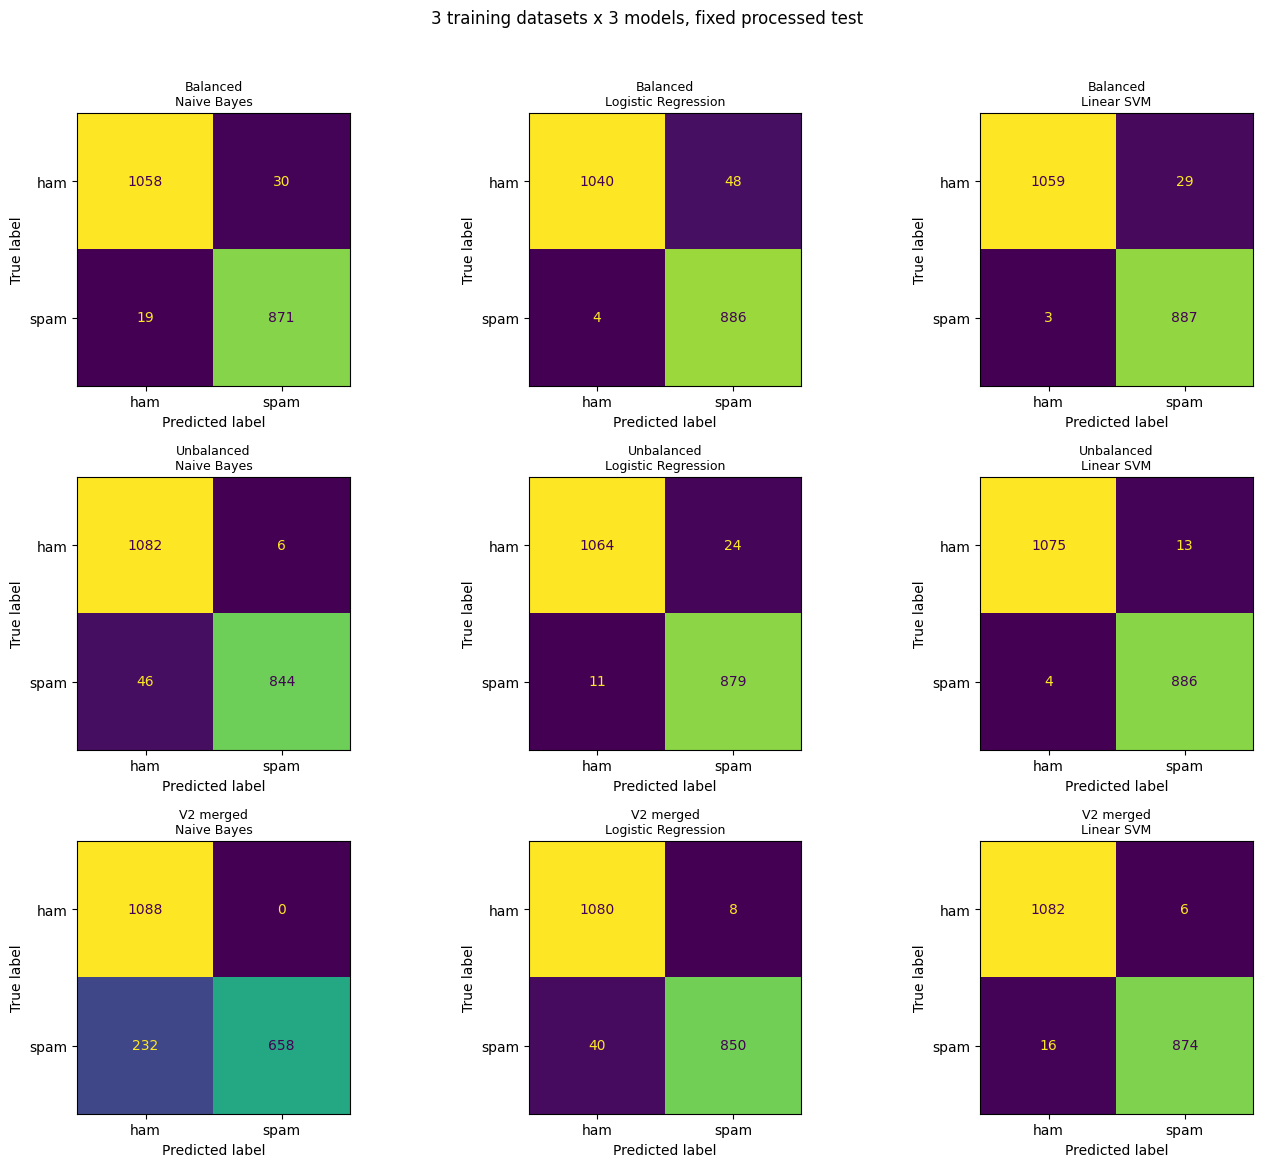

In [15]:
three_data_context = utils.run_three_data_model_comparison(split_context, data_v2, model_checker)
train_modes_3data = three_data_context["train_modes"]
v2_merged_train = three_data_context["v2_merged_train"]
results_9matrix = three_data_context["results"]
matrices_9 = three_data_context["matrices"]

In [16]:
# Lọc và tính toán TPR tương ứng với FPR = 1% trên tập test cho các mô hình ở Step 6
from sklearn.metrics import roc_curve
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

estimators = {
    "Naive Bayes": MultinomialNB(alpha=1.0),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(dual="auto")
}

test_frame = split_context.base_test_data
text_col = split_context.text_column
y_test_bin = (test_frame["label"] == "spam").astype(int)

fpr_target = 0.01
rows = []

for mode_name, train_frame in three_data_context["train_modes"].items():
    for model_name, estimator in estimators.items():
        pipeline = Pipeline([
            ("tfidf", model_checker.make_tfidf_vectorizer()),
            ("model", estimator)
        ])
        pipeline.fit(train_frame[text_col], train_frame["label"])
        
        if hasattr(pipeline.named_steps["model"], "predict_proba"):
            scores = pipeline.predict_proba(test_frame[text_col])[:, 1]
        elif hasattr(pipeline.named_steps["model"], "decision_function"):
            scores = pipeline.decision_function(test_frame[text_col])
        else:
            continue
            
        fpr, tpr, thresholds = roc_curve(y_test_bin, scores)
        tpr_at_1percent_fpr = np.interp(fpr_target, fpr, tpr)
        
        rows.append({
            "training_strategy": mode_name,
            "model": model_name,
            "TPR_at_1percent_FPR": f"{tpr_at_1percent_fpr * 100:.2f}%"
        })

df_fpr_1 = pd.DataFrame(rows)
display(df_fpr_1)


,training_strategy,model,TPR_at_1percent_FPR
0,Balanced,Naive Bayes,94.61%
1,Balanced,Logistic Regression,94.49%
2,Balanced,Linear SVM,97.98%
3,Unbalanced,Naive Bayes,96.52%
4,Unbalanced,Logistic Regression,96.07%
5,Unbalanced,Linear SVM,98.76%
6,V2 merged,Naive Bayes,94.94%
7,V2 merged,Logistic Regression,96.29%
8,V2 merged,Linear SVM,98.88%


### STEP 9.1 — Build TF-IDF Matrix For Checking


In [17]:
scratch_context = utils.prepare_scratch_context(split_context, model_checker)
X_train_scratch = scratch_context.x_train_matrix
X_test_scratch = scratch_context.x_test_matrix
y_train_scratch = scratch_context.y_train
y_test_scratch = scratch_context.y_test

Scratch/check train matrix: (3000, 55476)
Scratch/check test matrix: (1000, 55476)


### STEP 9.2 — Train Three Models From Scratch

Ba class tự code trong `model_from_scratch.py`: ScratchMultinomialNB, ScratchLogisticRegression, ScratchLinearSVM.


,algorithm,class_called_in_notebook,scratch_accuracy
0,Multinomial Naive Bayes,ScratchMultinomialNB,0.965
1,Logistic Regression,ScratchLogisticRegression,0.923
2,Linear SVM,ScratchLinearSVM,0.960


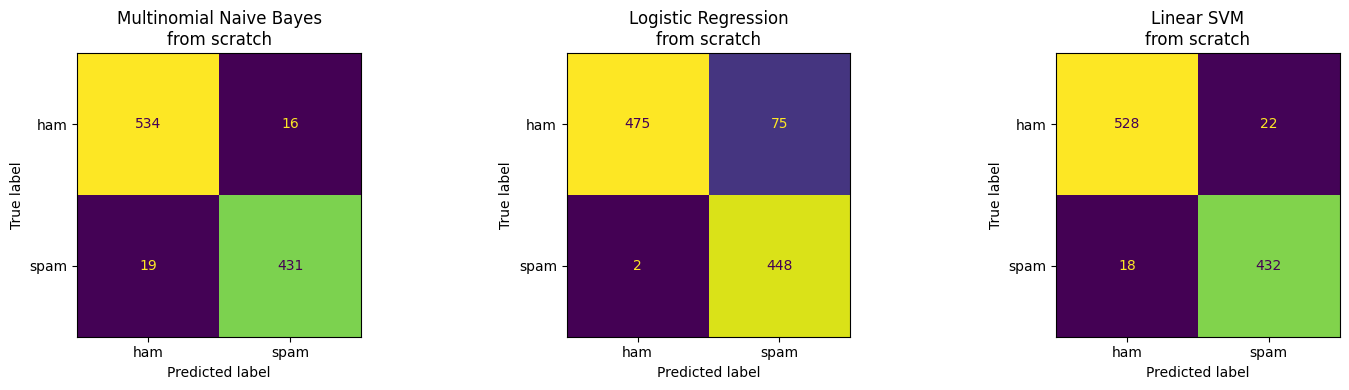

In [18]:
scratch_results = utils.train_scratch_models(scratch_context)
scratch_models = scratch_results["models"]
scratch_predictions_by_model = scratch_results["predictions_by_model"]
scratch_summary = scratch_results["summary"]

### STEP 9.3 — Double Check With Sklearn


In [19]:
model_check_differences = utils.compare_scratch_with_sklearn(scratch_context, scratch_results)

,algorithm,scratch_accuracy,sklearn_accuracy,accuracy_diff_abs,prediction_disagreement_rate,mismatch_count,checked_rows
0,Multinomial Naive Bayes,0.965,0.965,0.000,0.000,0,1000
1,Logistic Regression,0.923,0.964,0.041,0.043,43,1000
2,Linear SVM,0.960,0.981,0.021,0.037,37,1000


### STEP 9.4 — Baseline Model Training & Evaluation


In [20]:
model, predictions, baseline_accuracy, model_accuracy = model_checker.train_project_model(x_train, y_train, x_test, y_test)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Naive Bayes accuracy: {model_accuracy:.4f}")

Baseline accuracy: 0.5501
Naive Bayes accuracy: 0.9752


              precision    recall  f1-score   support

         ham       0.98      0.97      0.98      1088
        spam       0.97      0.98      0.97       890

    accuracy                           0.98      1978
   macro avg       0.97      0.98      0.98      1978
weighted avg       0.98      0.98      0.98      1978



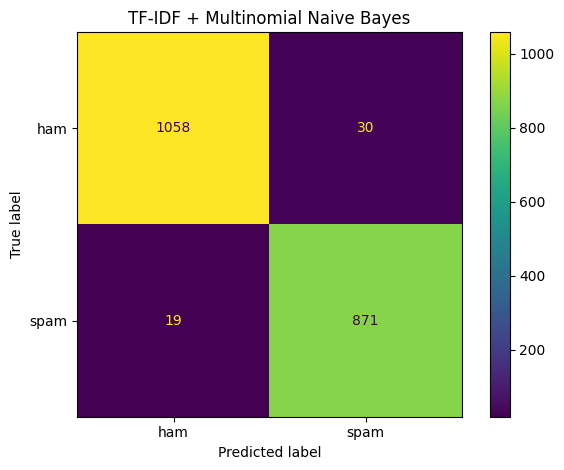

In [21]:
print(eda.classification_report_text(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.title("TF-IDF + Multinomial Naive Bayes")
plt.tight_layout()
plt.show()

### STEP 9.4 Notes — Reading The Metrics


In [22]:
display(eda.top_tokens(model, top_n=15))

label,ham,spam
rank,,
1,enron,free
2,ect,money
3,hou,online
4,hou ect,information
5,thanks,best
6,ect ect,new
7,pm,mail
8,know,time
9,attached,want


In [23]:
display(eda.per_source_scores(test_data, predictions).head(15))

,source_family,rows,accuracy,macro_precision,macro_recall,macro_f1
10,spamassassin,267,0.898876,0.889025,0.913688,0.895201
8,kaggle_email_spam_classification,191,0.931937,0.930930,0.934939,0.931667
6,huggingface_enron_spam,156,0.987179,0.987171,0.987171,0.987171
2,aueb_enron3_spam_ham,198,0.989899,0.990099,0.989899,0.989898
4,aueb_enron5_spam_ham,152,0.993421,0.994624,0.991667,0.993096
5,aueb_enron6_spam_ham,179,0.994413,0.994118,0.994737,0.994396
7,huggingface_kimdongh_spam_dataset,183,0.994536,0.994737,0.994382,0.994530
3,aueb_enron4_spam_ham,186,0.994624,0.994949,0.994318,0.994605
1,aueb_enron2_spam_ham,195,0.994872,0.994898,0.994898,0.994872
0,aueb_enron1_spam_ham,187,1.000000,1.000000,1.000000,1.000000


### STEP 9.5 — Cross-Source Holdout Check


In [24]:
display(eda.cross_source_holdout(before_balance_data, TEXT_COLUMN, paths["metrics_dir"]).head(15))

,holdout_source,rows,labels,accuracy,macro_f1
0,spamassassin_20021010_hard_ham,66,ham,0.257576,0.409639
1,spamassassin_20021010_easy_ham,101,ham,0.653465,0.790419
2,spamassassin_20030228_easy_ham,71,ham,0.690141,0.816667
3,kaggle_email_spam_classification,795,"ham,spam",0.905660,0.891409
5,huggingface_enron_spam,652,"ham,spam",0.972393,0.970670
6,aueb_enron4_spam_ham,693,"ham,spam",0.974026,0.971640
7,aueb_enron6_spam_ham,672,"ham,spam",0.974702,0.972724
8,aueb_enron1_spam_ham,705,"ham,spam",0.975887,0.973683
9,huggingface_kimdongh_spam_dataset,694,"ham,spam",0.982709,0.981308
11,aueb_enron2_spam_ham,737,"ham,spam",0.985075,0.983369


### STEP 9.6 — Optional Model Comparison


In [25]:
display(model_checker.compare_models(before_balance_data, TEXT_COLUMN, sample_rows=50_000))

,model,accuracy,macro_precision,macro_recall,macro_f1
2,Linear SVM,0.980324,0.977928,0.979477,0.978694
1,Logistic Regression,0.967593,0.968927,0.960642,0.964544
0,Naive Bayes,0.928627,0.948917,0.901431,0.918718


## STEP 10 — Validation-Tuned Threshold For Balanced / Unbalanced / V2

Dò tìm ngưỡng tốt trên tập Validation với điều kiện ràng buộc FPR <= 1%, và đánh giá trên tập Test.


Thresholds are selected on validation only; final metrics are evaluated on test only.


,split,rows,ham,spam
0,train_pool_base,5931,3259,2672
1,data_v2_extra_train_only,5705,5705,0
2,validation,1977,1086,891
3,test,1978,1088,890


,training_strategy,train_rows,ham_train,spam_train,source_families
0,Balanced,5344,2672,2672,11
1,Unbalanced,5931,3259,2672,11
2,V2 merged,11259,8587,2672,13


,training_strategy,feature_set,model,text_column,score_type,train_rows,ham_train,spam_train,selected_threshold,validation_FPR,...,FP,FN,TP,accuracy,precision,TPR,FPR,FNR,balanced_accuracy,can_reach_99_1_on_validation
14,V2 merged,Text + metadata,Linear SVM (Meta C1),clean_plus_meta,decision_score,11259,8587,2672,0.0448,0.0074,...,5,4,886,0.9954,0.9944,0.9955,0.0046,0.0045,0.9955,True
9,Unbalanced,Text + metadata,Linear SVM (Meta C1),clean_plus_meta,decision_score,5931,3259,2672,0.1196,0.0018,...,5,5,885,0.9949,0.9944,0.9944,0.0046,0.0056,0.9949,True
10,V2 merged,Text only,Naive Bayes,clean_text,probability,11259,8587,2672,0.1210,0.0092,...,6,79,811,0.9570,0.9927,0.9112,0.0055,0.0888,0.9529,False
13,V2 merged,Text + metadata,Linear SVM (Meta C0.5),clean_plus_meta,decision_score,11259,8587,2672,0.0113,0.0083,...,7,2,888,0.9954,0.9922,0.9978,0.0064,0.0022,0.9957,True
8,Unbalanced,Text + metadata,Linear SVM (Meta C0.5),clean_plus_meta,decision_score,5931,3259,2672,0.0908,0.0028,...,7,4,886,0.9944,0.9922,0.9955,0.0064,0.0045,0.9945,True
4,Balanced,Text + metadata,Linear SVM (Meta C1),clean_plus_meta,decision_score,5344,2672,2672,0.0889,0.0064,...,10,2,888,0.9939,0.9889,0.9978,0.0092,0.0022,0.9943,True
3,Balanced,Text + metadata,Linear SVM (Meta C0.5),clean_plus_meta,decision_score,5344,2672,2672,0.0727,0.0074,...,11,2,888,0.9934,0.9878,0.9978,0.0101,0.0022,0.9938,True
7,Unbalanced,Text only,Linear SVM (Calibrated),clean_text,probability,5931,3259,2672,0.4909,0.0092,...,14,14,876,0.9858,0.9843,0.9843,0.0129,0.0157,0.9857,True
11,V2 merged,Text only,Logistic Regression,clean_text,probability,11259,8587,2672,0.4428,0.0074,...,14,27,863,0.9793,0.9840,0.9697,0.0129,0.0303,0.9784,False
1,Balanced,Text only,Logistic Regression,clean_text,probability,5344,2672,2672,0.6171,0.0092,...,14,38,852,0.9737,0.9838,0.9573,0.0129,0.0427,0.9722,False


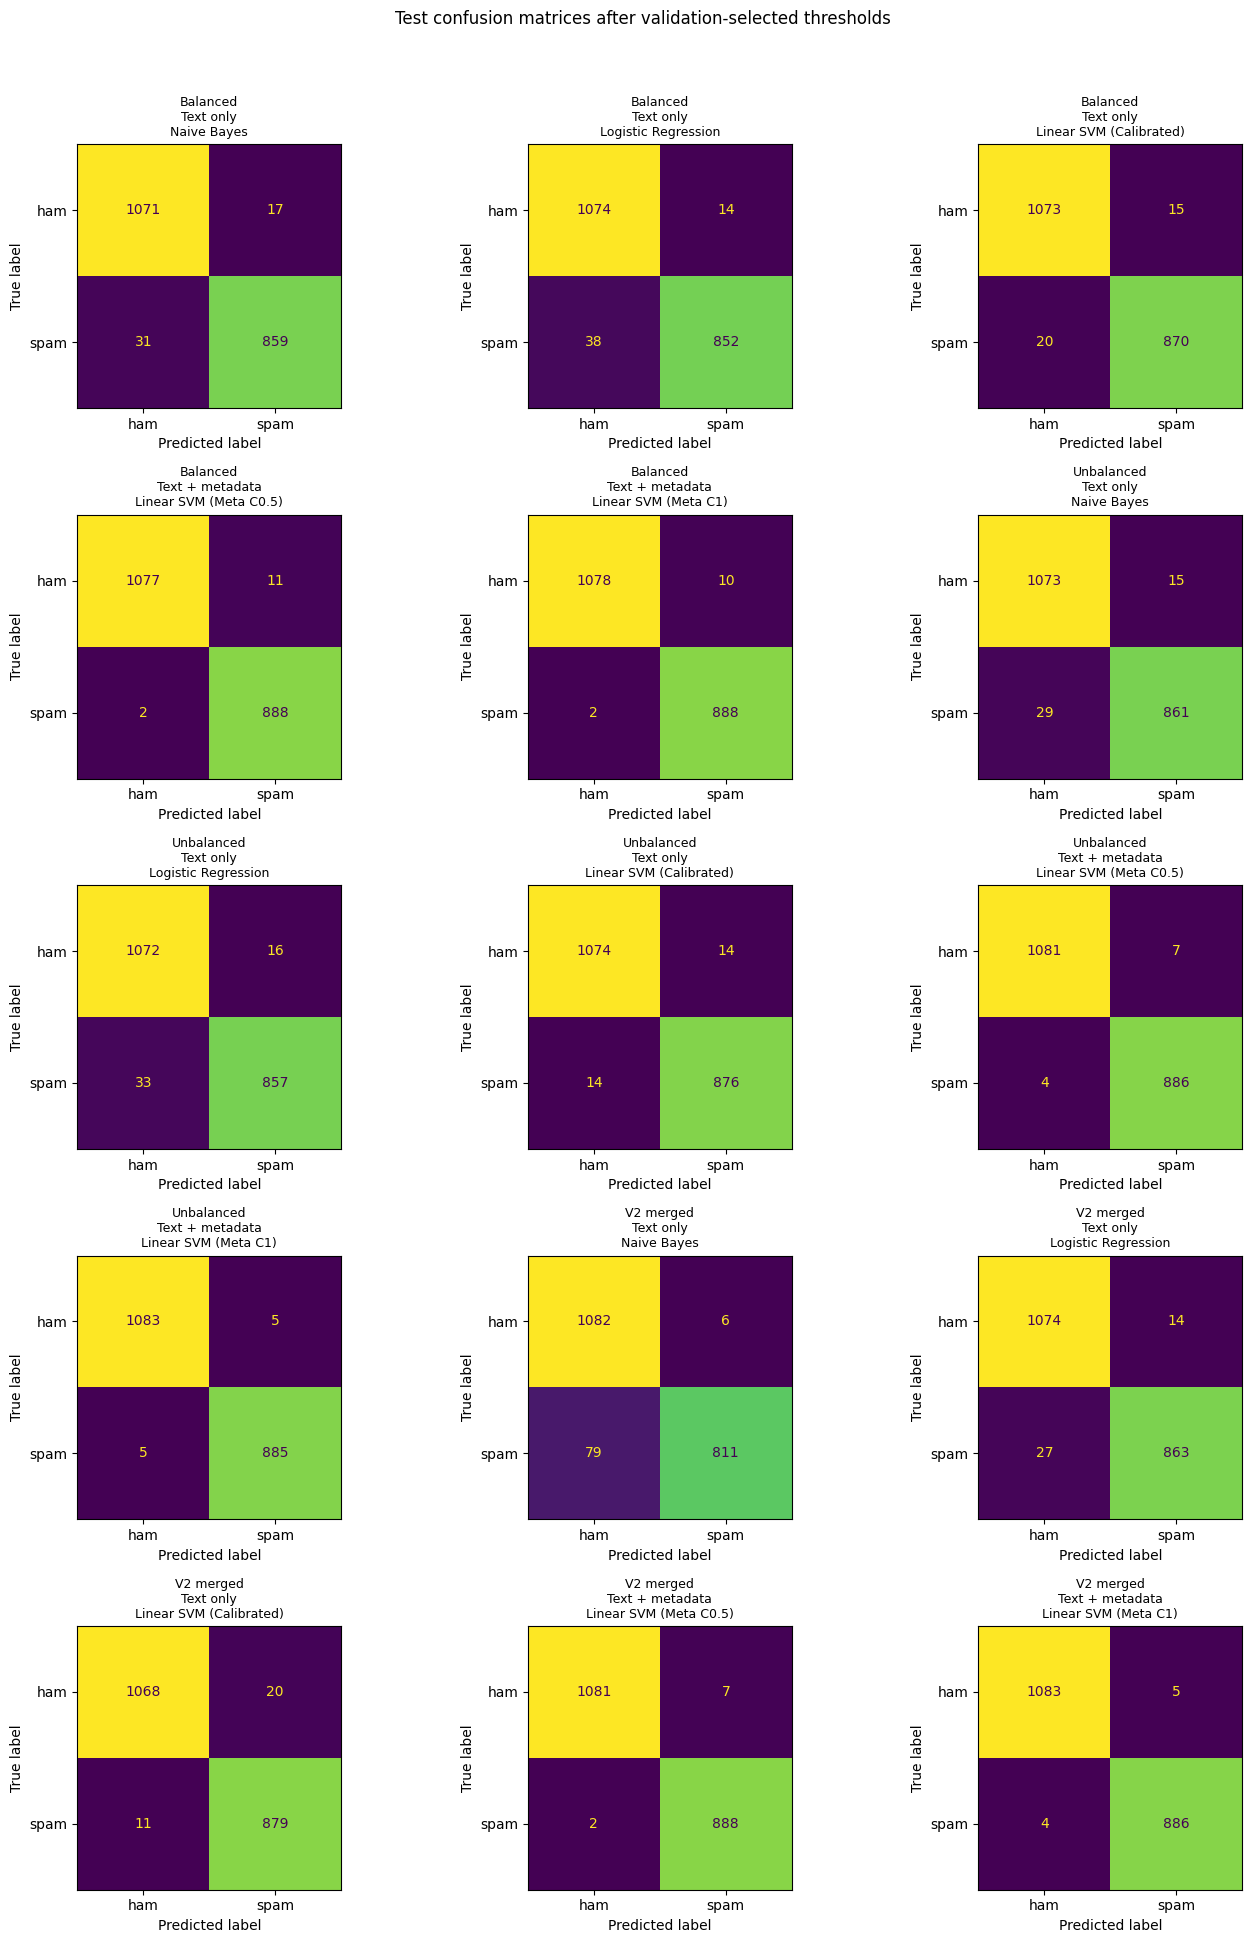

Validation-selected candidate: Balanced / Text + metadata / Linear SVM (Meta C1) (selection validation FPR limit <= 0.0075) -> validation TPR=0.9989, validation FPR=0.0064; test TPR=0.9978, test FPR=0.0092, threshold=0.0889
Diagnostic only - best observed test TPR with test FPR <= 1%: Balanced / Text + metadata / Linear SVM (Meta C1) -> TPR=0.9978, FPR=0.0092, threshold=0.0889
At least one validation-tuned model reaches TPR >= 99% and FPR <= 1% on test.


In [26]:
TARGET_FPR = 0.01
TARGET_TPR = 0.99
positive_label = "spam"
negative_label = "ham"
matrix_labels = [negative_label, positive_label]

threshold_context = utils.run_threshold_tuning(
    processed_data,
    data_v2,
    model_checker,
    target_fpr=TARGET_FPR,
    target_tpr=TARGET_TPR,
    positive_label=positive_label,
    negative_label=negative_label,
)
threshold_results = threshold_context["threshold_results"]
validation_roc_curves = threshold_context["validation_roc_curves"]
confusion_matrices = threshold_context["confusion_matrices"]
threshold_specs = threshold_context["threshold_specs"]
validation_choice = threshold_context["validation_choice"]
threshold_text_column = threshold_context["text_column"]
train_pool = threshold_context["train_pool"]
validation_frame = threshold_context["validation_frame"]
threshold_test_frame = threshold_context["test_frame"]
threshold_train_modes = threshold_context["train_modes"]

### STEP 10.1 — Low-FPR ROC View


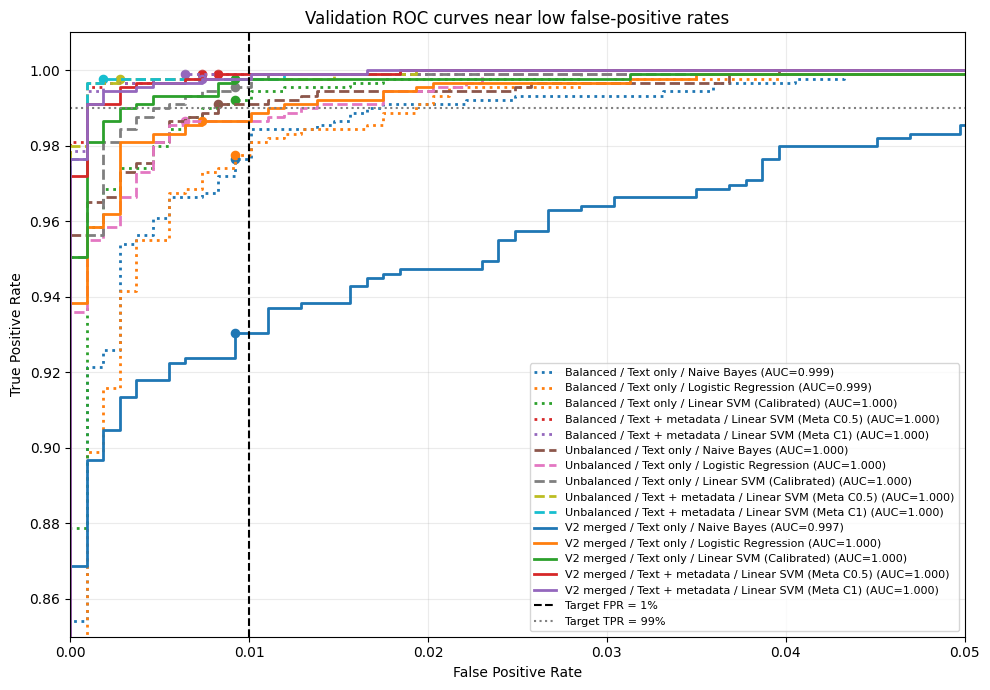

FPR                       \
training_strategy                       Balanced Unbalanced V2 merged   
feature_set     model                                                   
Text + metadata Linear SVM (Meta C0.5)    0.0101     0.0064    0.0064   
                Linear SVM (Meta C1)      0.0092     0.0046    0.0046   
Text only       Linear SVM (Calibrated)   0.0138     0.0129    0.0184   
                Logistic Regression       0.0129     0.0147    0.0129   
                Naive Bayes               0.0156     0.0138    0.0055   

                                             TPR                       \
training_strategy                       Balanced Unbalanced V2 merged   
feature_set     model                                                   
Text + metadata Linear SVM (Meta C0.5)    0.9978     0.9955    0.9978   
                Linear SVM (Meta C1)      0.9978     0.9944    0.9955   
Text only       Linear SVM (Calibrated)   0.9775     0.9843    0.9876   
                Logistic Regression       0.9573     0.9629    0.9697   
                Naive Bayes               0.9652     0.9674    0.9112   

                                        balanced_accuracy             \
training_strategy                                Balanced Unbalanced   
feature_set     model                                                  
Text + metadata Linear SVM (Meta C0.5)             0.9938     0.9945   
                Linear SVM (Meta C1)               0.9943     0.9949   
Text only       Linear SVM (Calibrated)            0.9819     0.9857   
                Logistic Regression                0.9722     0.9741   
                Naive Bayes                        0.9748     0.9768   

                                                  precision             \
training_strategy                       V2 merged  Balanced Unbalanced   
feature_set     model                                                    
Text + metadata Linear SVM (Meta C0.5)     0.9957    0.9878     0.9922   
                Linear SVM (Meta C1)       0.9955    0.9889     0.9944   
Text only       Linear SVM (Calibrated)    0.9846    0.9831     0.9843   
                Logistic Regression        0.9784    0.9838     0.9817   
                Naive Bayes                0.9529    0.9806     0.9829   

                                                   
training_strategy                       V2 merged  
feature_set     model                              
Text + metadata Linear SVM (Meta C0.5)     0.9922  
                Linear SVM (Meta C1)       0.9944  
Text only       Linear SVM (Calibrated)    0.9778  
                Logistic Regression        0.9840  
                Naive Bayes                0.9927

In [27]:
threshold_strategy_compare = utils.plot_low_fpr_roc(threshold_context)

### STEP 10.2 — Data Failure Analysis For 99/1 Target


Failure analysis model: Balanced / Linear SVM (Meta C1) with threshold=0.0889, score_type=decision_score


,source_profile,sources,rows,ham,spam
0,mixed,10,12960,8291,4669


label,source_family,ham,spam,total,spam_rate,source_profile
9,spamassassin,4091,668,4759,0.140366,mixed
2,aueb_enron3_spam_ham,493,494,987,0.500507,mixed
8,kaggle_email_spam_classification,437,547,984,0.555894,mixed
1,aueb_enron2_spam_ham,490,488,978,0.498978,mixed
0,aueb_enron1_spam_ham,491,456,947,0.481521,mixed
3,aueb_enron4_spam_ham,492,444,936,0.474359,mixed
7,huggingface_kimdongh_spam_dataset,471,446,917,0.486369,mixed
5,aueb_enron6_spam_ham,480,423,903,0.468439,mixed
6,huggingface_enron_spam,384,404,788,0.512690,mixed
4,aueb_enron5_spam_ham,462,299,761,0.392904,mixed


,source_family,rows,ham_rows,spam_rows,FP,FN,TP,TN,FPR,FNR,TPR
8,kaggle_email_spam_classification,191,86,105,5,2,103,81,0.0581,0.019,0.981
10,spamassassin,267,169,98,1,0,98,168,0.0059,0.000,1.000
2,aueb_enron3_spam_ham,198,99,99,1,0,99,98,0.0101,0.000,1.000
3,aueb_enron4_spam_ham,186,98,88,1,0,88,97,0.0102,0.000,1.000
7,huggingface_kimdongh_spam_dataset,183,94,89,1,0,89,93,0.0106,0.000,1.000
5,aueb_enron6_spam_ham,179,95,84,1,0,84,94,0.0105,0.000,1.000
1,aueb_enron2_spam_ham,195,98,97,0,0,97,98,0.0000,0.000,1.000
0,aueb_enron1_spam_ham,187,97,90,0,0,90,97,0.0000,0.000,1.000
6,huggingface_enron_spam,156,76,80,0,0,80,76,0.0000,0.000,1.000
4,aueb_enron5_spam_ham,152,92,60,0,0,60,92,0.0000,0.000,1.000


,label,rows,near_threshold_rows,near_threshold_rate,score_min,score_median,score_max
0,ham,1088,6,0.0055,-2.9360,-1.1481,0.3612
1,spam,890,2,0.0022,-0.0241,1.0339,2.0237


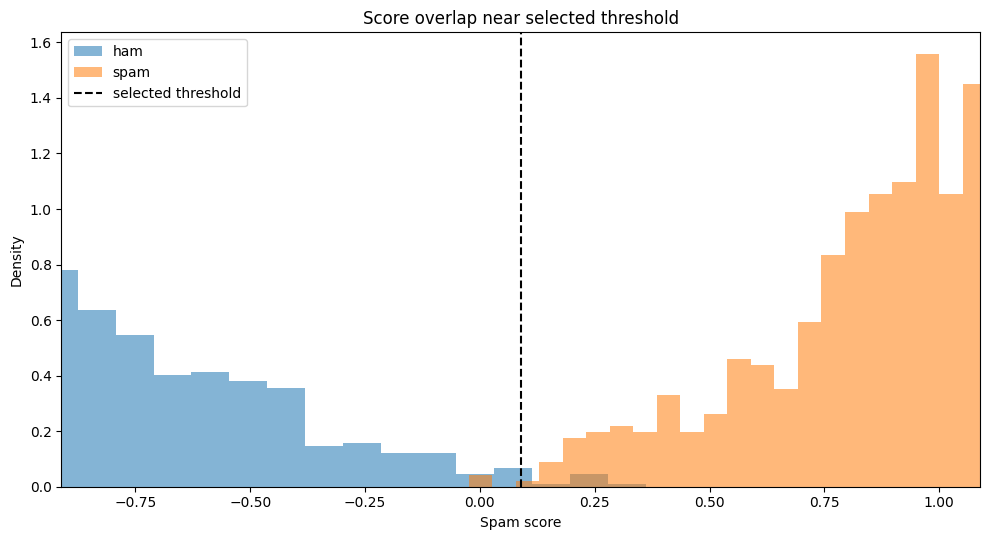

False positives closest to threshold


,error_type,label,prediction,score,threshold_distance,source_family,subject,snippet
930,FP,ham,spam,0.0936,0.0047,spamassassin,More Freebies with Ryanair.com,freebies ryanair extended free seat sale thurs...
1858,FP,ham,spam,0.0945,0.0056,kaggle_email_spam_classification,,june home world politics scitech health entert...
414,FP,ham,spam,0.1016,0.0127,aueb_enron3_spam_ham,hanover,hanover hanover stock price closed today recen...
564,FP,ham,spam,0.1070,0.0181,kaggle_email_spam_classification,,author abartlet mon apr new revision websvn we...
1016,FP,ham,spam,0.1857,0.0968,kaggle_email_spam_classification,,bignum entirely unused builds just fine lint e...
1789,FP,ham,spam,0.2038,0.1149,huggingface_kimdongh_spam_dataset,,transfer binary thu jun edt wp usaeekaminska d...
680,FP,ham,spam,0.2210,0.1321,aueb_enron4_spam_ham,* information only * work on the floor tonight,information work floor tonight tonight having ...
936,FP,ham,spam,0.2309,0.1420,kaggle_email_spam_classification,,multi message format picked alternative ag nci...
1376,FP,ham,spam,0.2347,0.1458,kaggle_email_spam_classification,,pierre philippe contacted allison bailey ask v...
1397,FP,ham,spam,0.3612,0.2723,aueb_enron6_spam_ham,moneycentral : 6 routes to retire rich,moneycentral routes retire rich ecial msn subj...


False negatives closest to threshold


,error_type,label,prediction,score,threshold_distance,source_family,subject,snippet
983,FN,spam,ham,-0.0025,0.0914,kaggle_email_spam_classification,,range crown papers definition principal annual...
1746,FN,spam,ham,-0.0241,0.1130,kaggle_email_spam_classification,,indicates parameter optional image multiple sl...


,rows,labels,sources,text_preview


,error_type,token,count
0,FP,ldb,46
1,FP,dn,35
2,FP,ret,26
3,FP,res,24
4,FP,site,19
5,FP,ctx,16
6,FP,watch,15
7,FP,aids,15
8,FP,news,14
9,FP,cbs,14


,issue,evidence,impact,next_action
0,Source-label confounding,0 ham-only source families with 0 rows; source...,Model can learn source/domain style instead of...,"Evaluate by source family, reduce source artif..."
1,Score overlap around threshold,Near threshold (+/-0.05): 6 ham and 2 spam rows.,Raising TPR pulls overlapping ham across thres...,Add stronger features such as URL/header/domai...
2,False positives / false negatives are source-p...,Top source errors include kaggle_email_spam_cl...,Some sources dominate residual errors; global ...,"Inspect source-specific samples, label noise, ..."
3,Exact conflicting clean_text labels,0 conflicting clean_text groups shown; total d...,"If conflicts exist, no threshold can classify ...",Deduplicate/resolve conflicting labels before ...
4,Token/artifact-driven errors,FP/FN top-token tables show the words most ass...,TF-IDF may be reacting to artifacts rather tha...,Extend cleaning and add robust non-text featur...


In [28]:
failure_context = utils.run_failure_analysis(threshold_context, before_balance_data, model_checker)
analysis_choice = failure_context["analysis_choice"]
analysis_errors = failure_context["analysis_errors"]
analysis_metrics = failure_context["analysis_metrics"]
source_confounding = failure_context["source_confounding"]
source_profile_summary = failure_context["source_profile_summary"]
source_errors = failure_context["source_errors"]
overlap_summary = failure_context["overlap_summary"]
conflicts = failure_context["conflicts"]
error_tokens = failure_context["error_tokens"]
issue_summary = failure_context["issue_summary"]

## STEP 11 — Save Model & Deployment Check

Lưu trữ mô hình và thử nghiệm dự đoán email mới.


In [29]:
saved_model_path = model_checker.save_model(model, paths["model"])
print(f"Saved model to {saved_model_path.relative_to(PROJECT_ROOT)}")

Saved model to models/spam_nb.joblib


In [30]:
display(model_checker.predict_new_emails(paths["model"]))

,email_text,clean_text,prediction,confidence
0,Win cash now! Click the prize link and claim y...,win cash prize link claim bonus today,spam,0.8824
1,"Hi team, attached are the meeting notes and ne...",hi team attached meeting notes steps today's p...,ham,0.9455


In [31]:
display(crawl.report_status(paths["metrics_dir"], PROJECT_ROOT))

print("\nSaved classification report:\n")
print(crawl.read_classification_report(paths["metrics_dir"]))

,report,status
0,data/processed/metrics/preprocessing_balance_r...,exists
1,data/processed/metrics/classification_report.txt,exists
2,data/processed/metrics/model_summary.md,exists
3,data/processed/metrics/per_source_classificati...,exists
4,data/processed/metrics/cross_source_holdout_re...,exists



Saved classification report:

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       896
        spam       0.98      0.98      0.98       892

    accuracy                           0.98      1788
   macro avg       0.98      0.98      0.98      1788
weighted avg       0.98      0.98      0.98      1788

